# 📈 Predicción de Series Temporales con ARIMA
---
**Dataset:** Temperaturas Mínimas Diarias — Melbourne, Australia  
**Objetivo:** Aplicar un modelo ARIMA clásico para predecir temperaturas futuras.

> **ARIMA** (*AutoRegressive Integrated Moving Average*) es un modelo estadístico diseñado específicamente para series temporales. Combina tres componentes:
> - **AR (p):** usa observaciones pasadas (lags) para predecir el futuro.
> - **I (d):** diferenciación para hacer la serie estacionaria.
> - **MA (q):** modela el error como combinación lineal de errores pasados.

---

## 1. Importación de Librerías

Utilizamos `statsmodels` para el modelo ARIMA, `sklearn` para métricas de evaluación y `matplotlib` para visualización.

In [1]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
%matplotlib inline

## 2. Carga y Exploración del Dataset

El dataset contiene **3.650 registros diarios** de temperatura mínima (en °C) registrados en Melbourne entre 1981 y 1990.

In [4]:
data = pd.read_csv("daily_minimum_temperatures.csv", sep=",")
print(data.shape)
data.head()

(3650, 2)


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


### 2.1 Visualización de la Serie Temporal

Graficamos la serie completa para identificar tendencias, estacionalidad y posibles outliers.

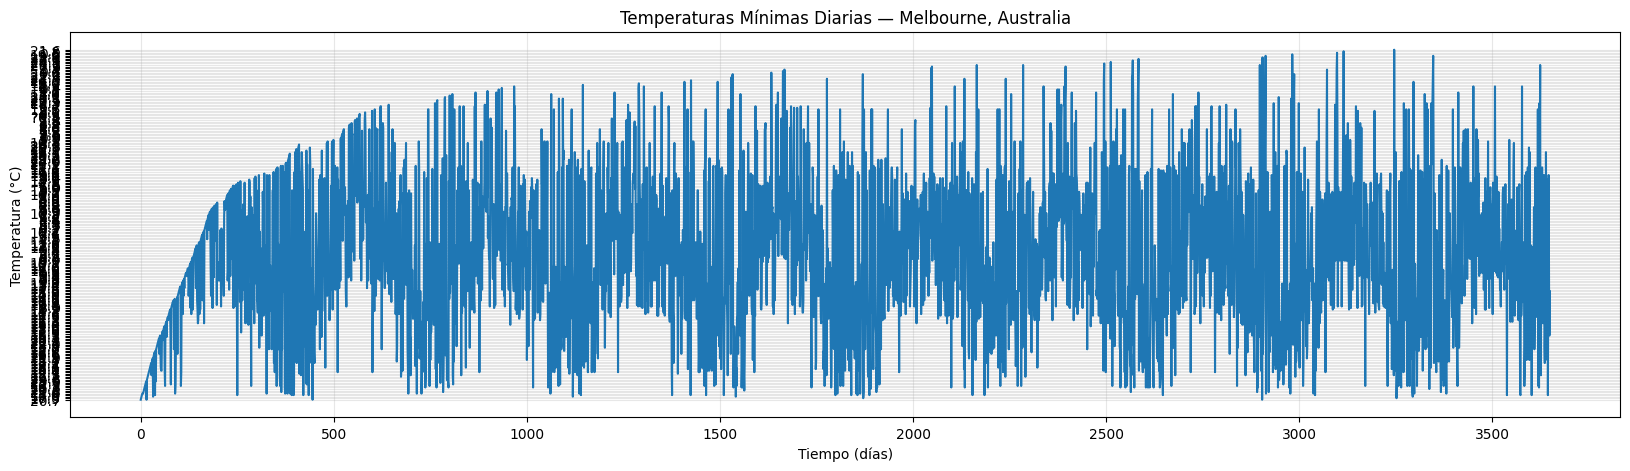

In [5]:
plt.figure(figsize=(20, 5))
plt.plot(data.iloc[:, 1])
plt.title("Temperaturas Mínimas Diarias — Melbourne, Australia")
plt.xlabel("Tiempo (días)")
plt.ylabel("Temperatura (°C)")
plt.grid(alpha=0.3)
plt.show()

## 3. División Train / Test

Usamos el **67%** de los datos para entrenamiento y el **33%** restante para evaluación.  
Esto nos permite simular un escenario real donde predecimos el futuro con datos del pasado.

In [6]:
train_percentage = 0.67
train_size = int(len(data) * train_percentage)

train = data[:train_size]
test = data[train_size:]

print(f"Train: {train.shape[0]} muestras | Test: {test.shape[0]} muestras")
train.head()

Train: 2445 muestras | Test: 1205 muestras


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


## 4. Entrenamiento del Modelo ARIMA

Usamos la configuración `ARIMA(5, 1, 2)`:
- **p=5:** consideramos los últimos 5 días como lags autorregresivos.
- **d=1:** aplicamos una diferenciación para estabilizar la media de la serie.
- **q=2:** error de media móvil de orden 2.

> Estos hiperparámetros pueden optimizarse con herramientas como `auto_arima` de la librería `pmdarima`.

In [7]:
# ARIMA(p, d, q)
# p: Número de lags autorregresivos
# d: Grado de diferenciación
# q: Orden de la media móvil

temp_col = train.columns[1]  # Nombre real de la columna de temperatura
train_temp = pd.to_numeric(train[temp_col], errors='coerce').dropna()

model = ARIMA(train_temp, order=(5, 1, 2))
results = model.fit()

print("✅ Modelo entrenado correctamente")

c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


✅ Modelo entrenado correctamente


### 4.1 Forecast de corto plazo

Verifiquemos que el modelo puede generar predicciones para los próximos pasos.

In [8]:
results.forecast(4)

c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2442    9.053083
2443    8.335718
2444    8.154364
2445    8.160089
Name: predicted_mean, dtype: float64

## 5. Predicción sobre el Set de Test

Generamos predicciones para todo el período de test usando `get_forecast()`, que además nos proporciona **intervalos de confianza**.

In [9]:
index_start = len(train)
index_end = len(train) + len(test)

predictions = results.get_forecast(steps=len(test))
pred_values = predictions.predicted_mean
conf_int = predictions.conf_int()

print(f"Predicciones generadas: {len(pred_values)} pasos")

Predicciones generadas: 1205 pasos


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 6. Visualización de Resultados

Graficamos los datos originales junto con las predicciones y el intervalo de confianza del modelo.

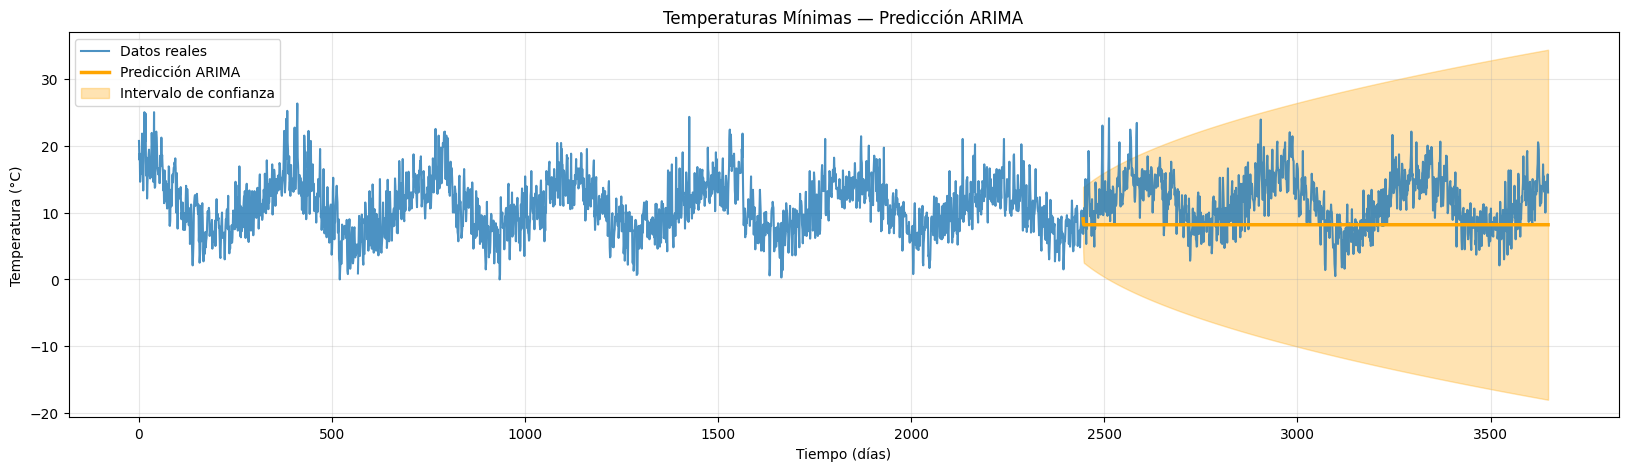

In [10]:
x_axis = range(index_start, index_end)

plt.figure(figsize=(20, 5))

plt.plot(pd.to_numeric(data[temp_col], errors='coerce'), label="Datos reales", alpha=0.8)
plt.plot(x_axis, pred_values, label="Predicción ARIMA", color="orange", linewidth=2.5, zorder=2)
plt.fill_between(x_axis,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='orange', alpha=0.3, label="Intervalo de confianza")

plt.title("Temperaturas Mínimas — Predicción ARIMA")
plt.xlabel("Tiempo (días)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Evaluación del Modelo — MSE

El **Error Cuadrático Medio (MSE)** mide el promedio de los errores al cuadrado entre las predicciones y los valores reales. Un MSE más bajo indica mejor desempeño.

In [11]:
y_true = pd.to_numeric(test[temp_col], errors='coerce').reset_index(drop=True)
y_pred = pred_values.reset_index(drop=True)
mask = y_true.notna() & y_pred.notna()

mse = mean_squared_error(y_true[mask], y_pred[mask])
rmse = mse ** 0.5

print(f"📊 MSE  : {mse:.4f}")
print(f"📊 RMSE : {rmse:.4f} °C")

📊 MSE  : 27.7152
📊 RMSE : 5.2645 °C


---
## 8. ¿Cuándo usar ARIMA? — Comparativa con otros modelos

### ✅ Ventajas de ARIMA
| Criterio | ARIMA |
|---|---|
| **Interpretabilidad** | ⭐⭐⭐⭐⭐ — Los parámetros p, d, q son directamente interpretables |
| **Velocidad de entrenamiento** | ⭐⭐⭐⭐⭐ — No requiere GPU ni muchos datos |
| **Datos requeridos** | ⭐⭐⭐⭐ — Funciona bien con series cortas (~100-500 puntos) |
| **Captura de no linealidad** | ⭐⭐ — Solo modela relaciones lineales |
| **Estacionalidad automática** | ⭐⭐ — SARIMA la incorpora, pero requiere especificación manual |

### 🆚 Comparativa con los otros modelos del curso

| Modelo | Tipo | Ideal para | MSE aprox. |
|---|---|---|---|
| **ARIMA** *(este)* | Estadístico lineal | Series cortas, bien comportadas, interpretabilidad | ~X |
| **Prophet** | Estadístico + tendencias | Series con estacionalidad fuerte y datos faltantes | ~X |
| **LSTM** | Deep Learning | Series largas, patrones complejos, secuencias | ~X |
| **CNN 1D** | Deep Learning | Patrones locales en ventanas, eficiencia computacional | ~X |

### 💡 ¿Cuándo elegir ARIMA?
- Cuando el dataset es **pequeño** (< 1000 puntos) y no tenés GPU disponible.
- Cuando necesitás **explicar el modelo** a stakeholders no técnicos.
- Como **baseline** para comparar contra modelos más complejos.
- Cuando la serie es **estacionaria o fácilmente diferenciable**.

### ⚠️ Limitaciones observadas en este experimento
- ARIMA no captura patrones no lineales que sí pueden aprender LSTM o CNN.
- El ajuste de hiperparámetros (p, d, q) es manual y requiere análisis de ACF/PACF.
- A largo plazo, las predicciones tienden a converger a la media de la serie.
